In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch import nn
import PINN
from PINN import reader, models, pl, tl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
# from TorchDiffEqPack import odesolve
from torchdiffeq import odeint

os.chdir("/home/wergillius/Project/PINN_dynamics")

import matplotlib.pyplot as plt
import seaborn as sns

/home/wergillius/.conda/envs/PINN_torch/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from torchdiffeq import odeint

In [3]:
from torch.utils.data import DataLoader

In [9]:
# CHANG THIS !!!!!
# ckpt_path = "logs/meahr_monocle-pseudotime_scaled_multiBnch/pde_singlebranch_twotimepoints/lightning_logs/version_21/checkpoints/epoch=11-total_loss=13.41408253.ckpt"
ckpt_path = "logs/meahr_monocle-pseudotime_scaled_multiBnch/pde_singlebranch_twotimepoints/lightning_logs/version_28/checkpoints/epoch=25-total_loss=2.78176117.ckpt"
# ckpt_path = "logs/meahr_monocle-pseudotime_scaled_multiBnch/pde_singlebranch_twotimepoints/lightning_logs/version_24/checkpoints/epoch=1-total_loss=8.52015209.ckpt"
model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"models.{model_name}")

In [10]:
PINN.models._pde_informed_params.pde_singlebranch_twotimepoints

PINN.models._pde_informed_params.pde_singlebranch_twotimepoints

In [11]:
pde_model = model_class.load_from_checkpoint(ckpt_path)

In [12]:
device = 'cuda:1'
pde_model = pde_model.to(device)

In [13]:
pde_model.g.y

Parameter containing:
tensor([1.5013, 0.9730, 0.9473, 0.7806, 1.4657, 1.2826, 1.0919, 0.8068, 0.5862],
       device='cuda:1', requires_grad=True)

In [14]:
pde_model.v.y

Parameter containing:
tensor([-3.4428, -3.2546, -3.2488, -2.7918, -3.0585, -3.0356, -3.1380, -3.1863,
        -3.4265], device='cuda:1', requires_grad=True)

In [15]:
pde_model.D.y

Parameter containing:
tensor([-8.6485, -8.5880, -8.8182, -8.6768, -8.3121, -9.4058, -9.1147, -9.3685,
        -8.6579], device='cuda:1', requires_grad=True)

# load data

In [11]:
# MODEL CLASS and define model
# pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

data_name = ckpt_path.split("/")[1].split("-")[0]
adata = sc.read_h5ad(f"data/{data_name}.h5ad")
timepoints = adata.uns['pop']['t']

cellstate_key = ckpt_path.split("/")[1].split("-")[1].replace("_multiBnch", "")

n_timepoint = 8
n_grid = 300

In [12]:
train_DS = reader.SingleBranch_AnnDS(AnnData=adata, 
                                n_timepoint = n_timepoint,
                                timepoint_key = 'time',
                                cellstate_key=cellstate_key,  #'Actb_Kcnn4_scaled_S'
                                n_grid=n_grid,  
                                log_transform=False,
                                replicate_key='batch',
                                norm_time = "min_minus")

def reduce_batchdim(batch):
    # for batch size 1 , remove the batch dimension
    if len(batch) == 1:
        batch = [ts.squeeze(0) for ts in batch[0]]
    return batch
batch_size = 1
train_DL = DataLoader(train_DS, batch_size=batch_size, num_workers=10, shuffle=True, collate_fn=reduce_batchdim)

In [13]:
Mean = torch.from_numpy(train_DS.pop_mean).clone().float()

In [14]:
u_b = torch.from_numpy(train_DS.u_b).clone().float().to(device)
s = torch.from_numpy(train_DS.s).clone().float().to(device)

In [15]:
u_b.sum(axis=1)

tensor([  1.0167,   1.7164,   5.2584,  14.3685,  59.6116, 134.8346, 318.3921,
        937.4299], device='cuda:1')

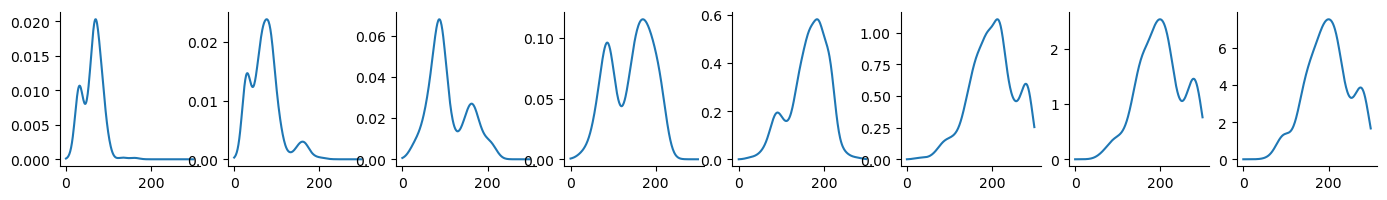

In [16]:
fig, axs = plt.subplots(1, len(u_b), figsize=(17,2), frameon=True)
for i in range(len(u_b)):
    axs[i].plot(u_b[i].cpu().numpy())
    sns.despine(ax=axs[i])

In [17]:
adata = train_DS.adata
adata

AnnData object with n_obs × n_vars = 10104 × 7006
    obs: 'barcodes', 'pseudodynamics_branch_class', 'palantir_pseudotime', 'branching_region', 'branch_class', 'time', 'batch', 'pseudotime', 'cell', 'batch_to_match', 'pseudotime_scaled'
    var: 'TC_MAGIC_pdt_r', 'NK_MAGIC_pdt_r'
    uns: 'DM_EigenValues', 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'pseudodynamics_branch_class_colors', 'umap'
    obsm: 'Cbl_Lpxn_scaled', 'Cbl_Rps6ka3_scaled', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_Cbl_Adam19', 'X_Cbl_Lpxn', 'X_Cbl_Mllt3', 'X_Cbl_Rps6ka3', 'X_dc', 'X_diffmap', 'X_pca', 'X_tsne', 'X_umap', 'branch_masks', 'diff component', 'fated_pdt', 'palantir_fate_probabilities', 'palantir_fated_pdt', 'pseudotime_scaled'
    varm: 'PCs', 'gene_trends_NK', 'gene_trends_TC'
    layers: 'Counts', 'MAGIC_imputed_data'
    obsp: 'D

In [18]:
adata.obsm['pseudotime_scaled'].max(), adata.obsm['pseudotime_scaled'].min()

(0.9565217391304348, 0.08695652173913045)

# simulation

In [7]:
train_DS.popD['t']

NameError: name 'train_DS' is not defined

In [20]:
train_DS.T_b

array([0., 1., 2., 3., 4., 5., 6., 7.])

In [21]:
t_list = train_DS.t_b[:,0] 

In [22]:
t_list

array([0., 1., 2., 3., 4., 5., 6., 7.])

# distribution simulation

In [23]:
t_list

array([0., 1., 2., 3., 4., 5., 6., 7.])

In [24]:
from torchdiffeq import odeint_adjoint as odeint

In [32]:
t_list = train_DS.t_b[:,0] 

# loss 2 : dynamics 
# init_condition 
u_int_all = [u_b[0].detach().cpu().numpy()]

with torch.no_grad():
	for it in range(len(t_list)-1):
		print(it)
		t1 = t_list[it+1].item()
		t0 = t_list[it].item()

		step_size = np.around((t1 - t0)/3, decimals=1).item() 
		step_size = step_size if step_size > 0 else 0.05

		step_size = min(step_size, 0.4)

		ut0 = u_b[it,:]
		utp1 = u_b[it+1,:]

		# init condition : ut, s in a square, u in a square
		init_condition = (ut0, s)
		u_int, s_int = odeint(
						pde_model,
						init_condition,
						torch.tensor([t0,t1]).type(torch.float32).to(device),
						atol=1e-6,
						rtol=1e-6,
						method='dopri5',
						# options = {'step_size': step_size}
				)

		# boundary u of  the next timepoint
		u_int = nn.functional.relu(u_int)

		u_int_all.append(u_int[-1].cpu().numpy())

0


1
2
3
4
5
6


70s : 1e-8
50s : 1e-6

In [33]:
u_int_all = np.stack(u_int_all)

In [34]:
u_int_all.shape

(8, 300)

In [35]:
u_b[:,:-1].sum(axis=1).cpu().numpy(), u_int_all[:,:-1].sum(axis=1)

(array([  1.0166811,   1.7163587,   5.258436 ,  14.368538 ,  59.610306 ,
        134.57964  , 317.63403  , 935.7692   ], dtype=float32),
 array([  1.0166811,   2.7979586,   4.792854 ,  15.286797 ,  44.861214 ,
        192.13477  , 401.8939   , 947.9447   ], dtype=float32))

In [8]:
import matplotlib.pyplot as plt

In [16]:
N = np.array([  1.0166811,   1.7163587,   5.258436 ,  14.368538 ,  59.610306 ,
        134.57964  , 317.63403  , 935.7692   ]),

N_thtea = np.array([  1.0166811,   2.7979586,   4.792854 ,  15.286797 ,  44.861214 ,
        192.13477  , 401.8939   , 947.9447   ])

In [ ]:
plt.plot(train_DS.popD['t'], np.log10(N), label='obsebed')
plt.plot(train_DS.popD['t'], np.log10(N_thtea), label='simulated')

In [36]:
p_b = u_b / u_b.sum()
p_b = p_b.detach().cpu().numpy()


In [37]:
np.hstack([u_b.detach().cpu().numpy(),np.zeros((8,1))]).shape

(8, 301)

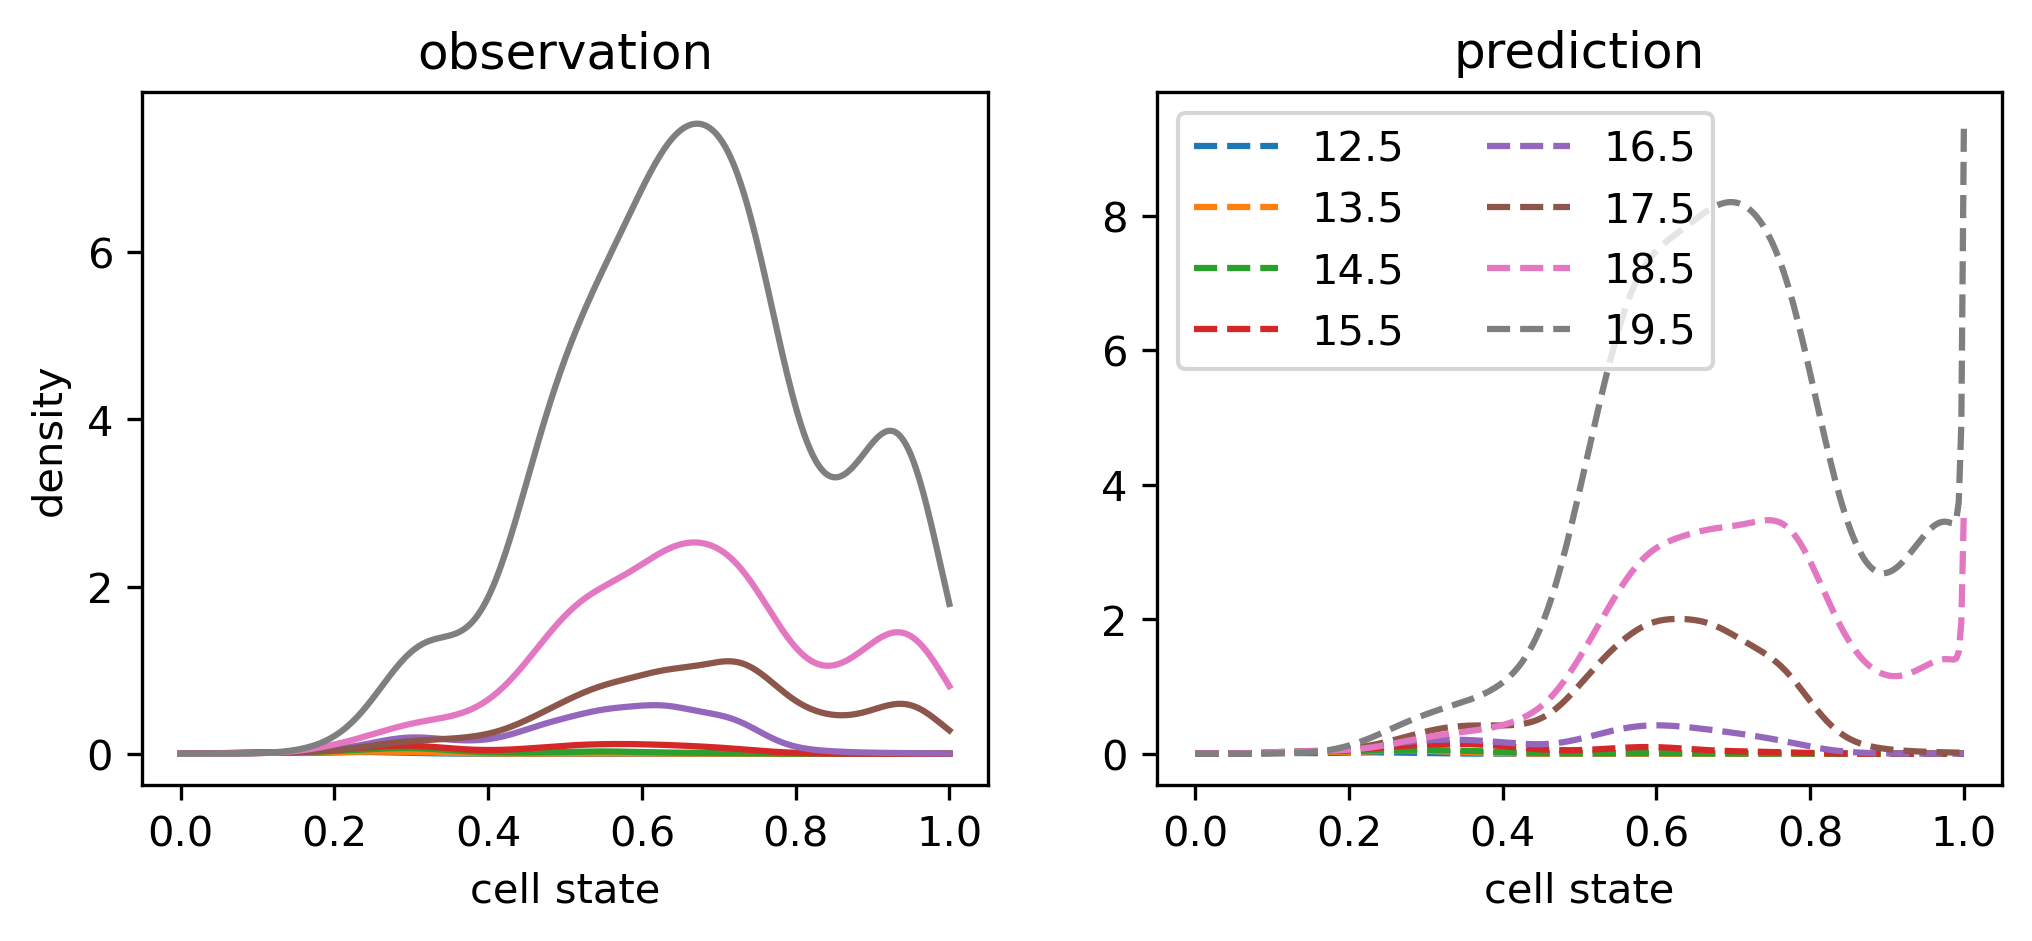

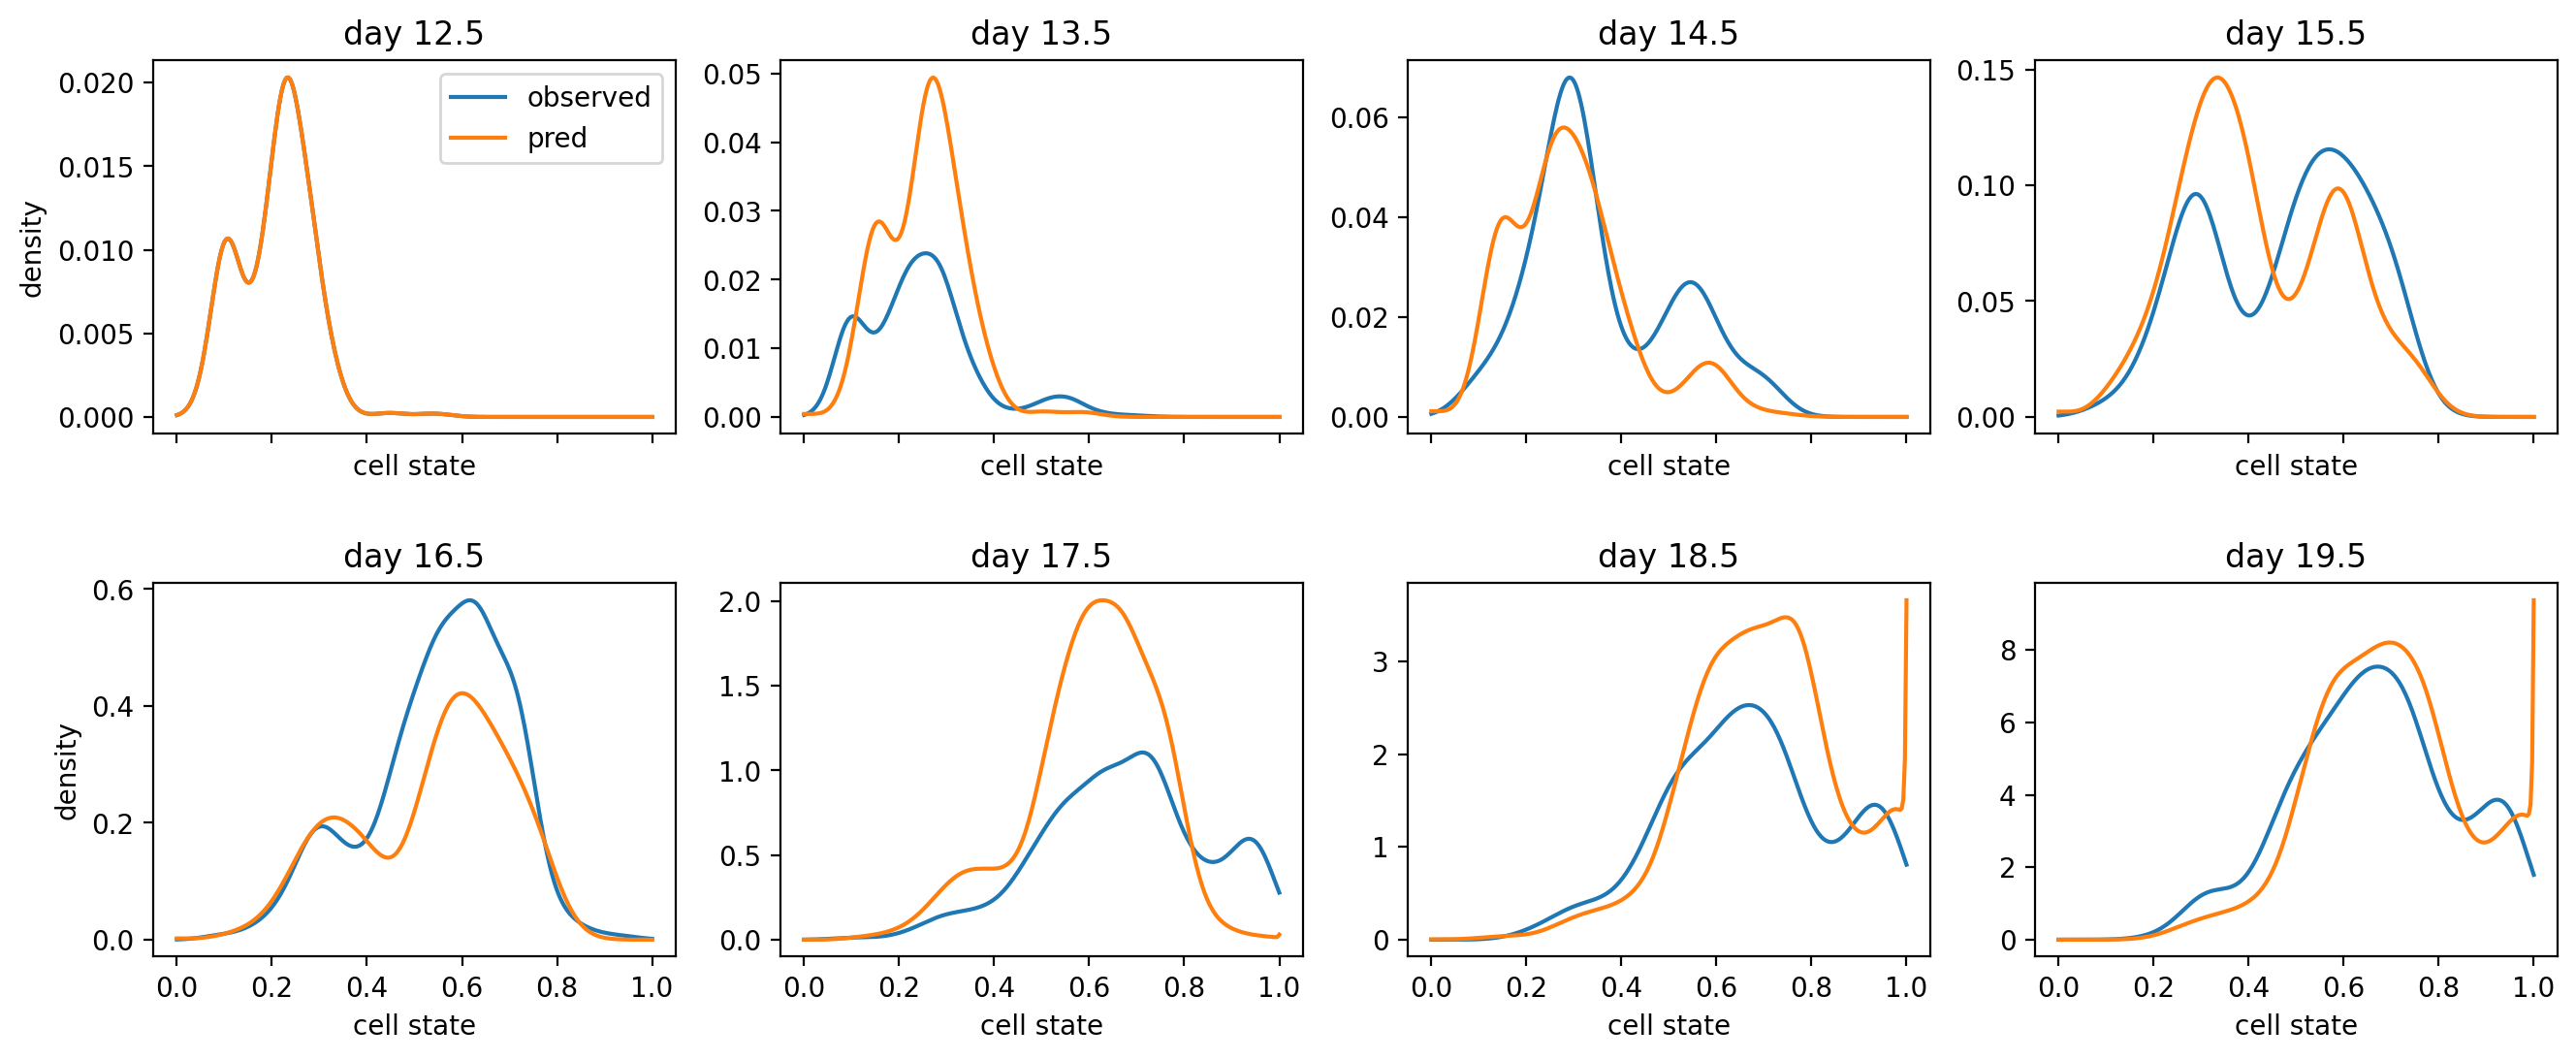

In [38]:
fp=299
u_expand = np.hstack([u_b.detach().cpu().numpy(),np.zeros((8,1))])
u_int_expand = np.hstack([u_int_all,np.zeros((8,1))])
PINN.pl.density_by_time(u_expand[:,:-2], u_int_expand[:,:-2] , train_DS.popD['t']);

# Long term integral

In [28]:
from torchdiffeq import odeint_adjoint as odeint

In [39]:
t_list = train_DS.t_b[:,0] 

# loss 2 : dynamics 
# init_condition 
u_int_all = [u_b[0].detach().cpu().numpy()]

with torch.no_grad():
	
	step_size = np.around((t_list[1] - t_list[0])/15, decimals=1).item() 
	step_size = step_size if step_size > 0 else 0.05

	step_size = min(step_size, 0.4)

	ut0 = u_b[0].detach()

	# init condition : ut, s in a square, u in a square
	init_condition = (ut0, s)
	u_int, s_int = odeint(
					pde_model,
					init_condition,
					torch.tensor(t_list).type(torch.float32).to(device),
					atol=1e-8,
					rtol=1e-8,
					method='dopri5',
					# options = {'step_size': step_size}
			)

	# boundary u of  the next timepoint
	u_int = nn.functional.relu(u_int)

In [40]:
u_int_all = u_int.detach().cpu().numpy()

In [41]:
u_b.sum(axis=1), u_int.sum(axis=1)

(tensor([  1.0167,   1.7164,   5.2584,  14.3685,  59.6116, 134.8346, 318.3921,
         937.4299], device='cuda:1'),
 tensor([1.0167e+00, 2.7980e+00, 7.5758e+00, 2.0815e+01, 6.0239e+01, 1.8623e+02,
         6.0567e+02, 2.0213e+03], device='cuda:1'))

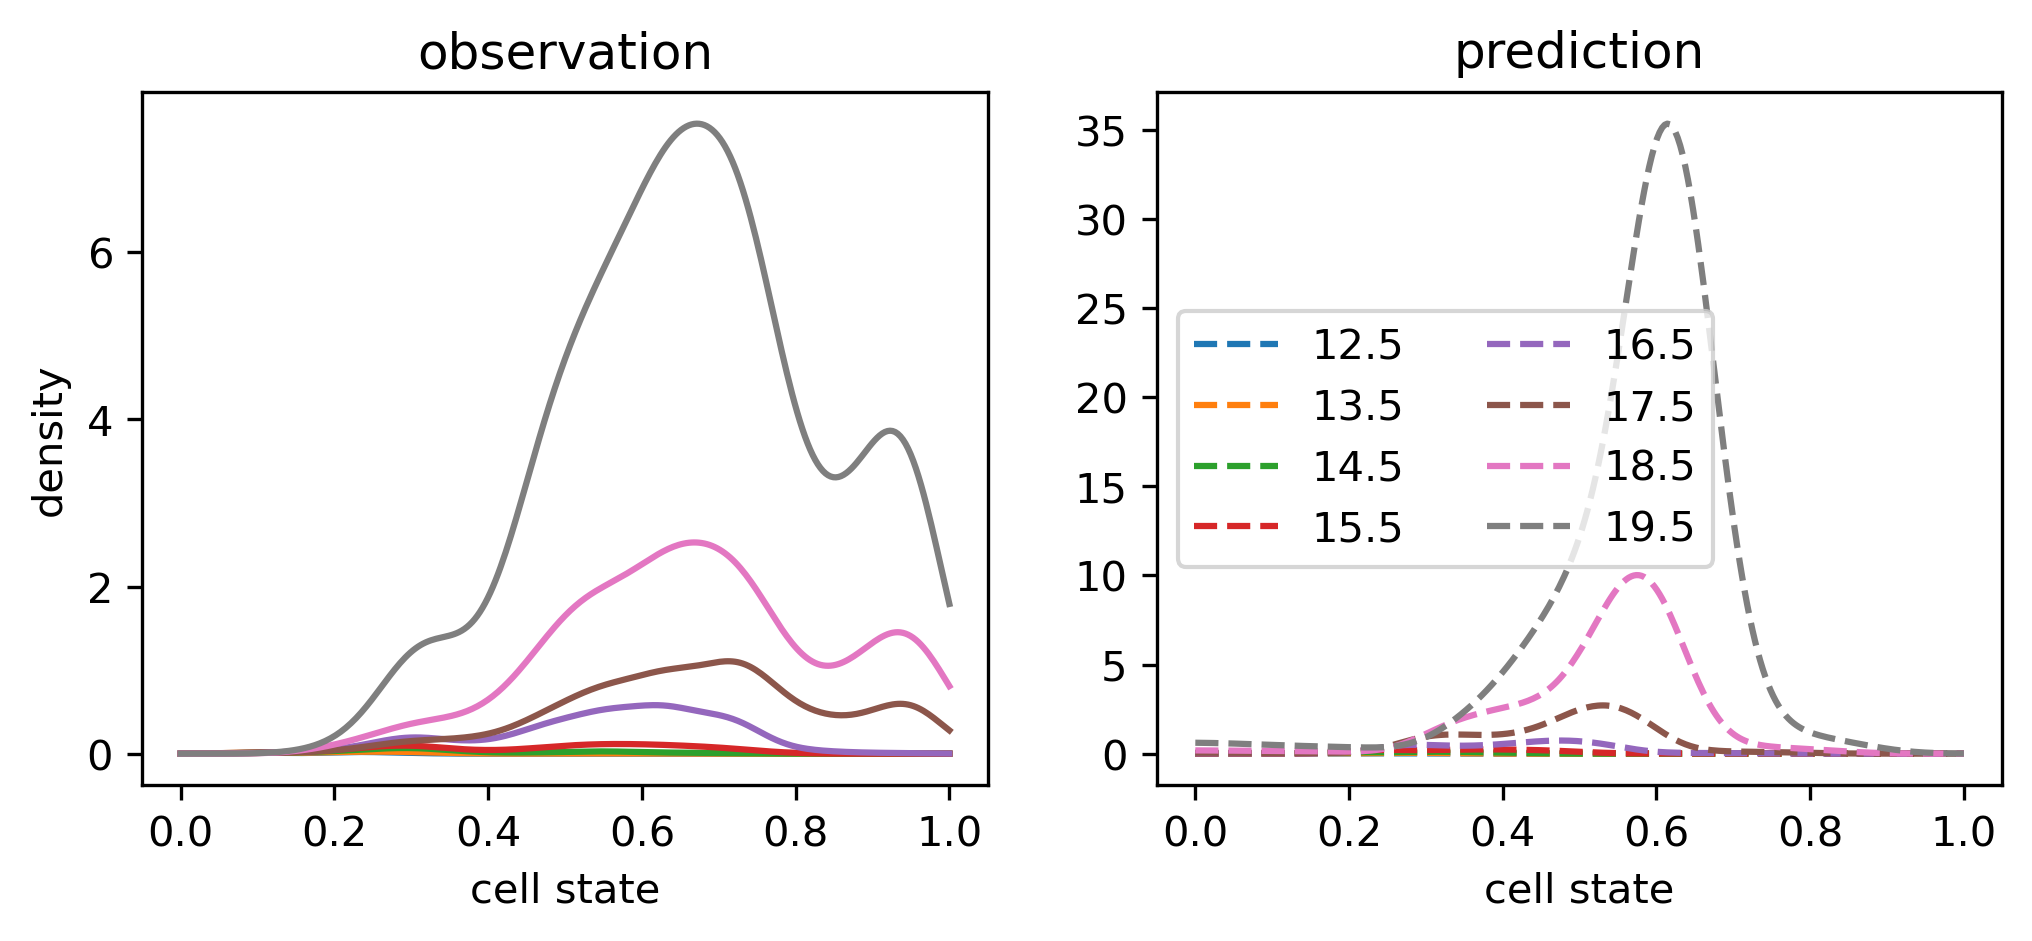

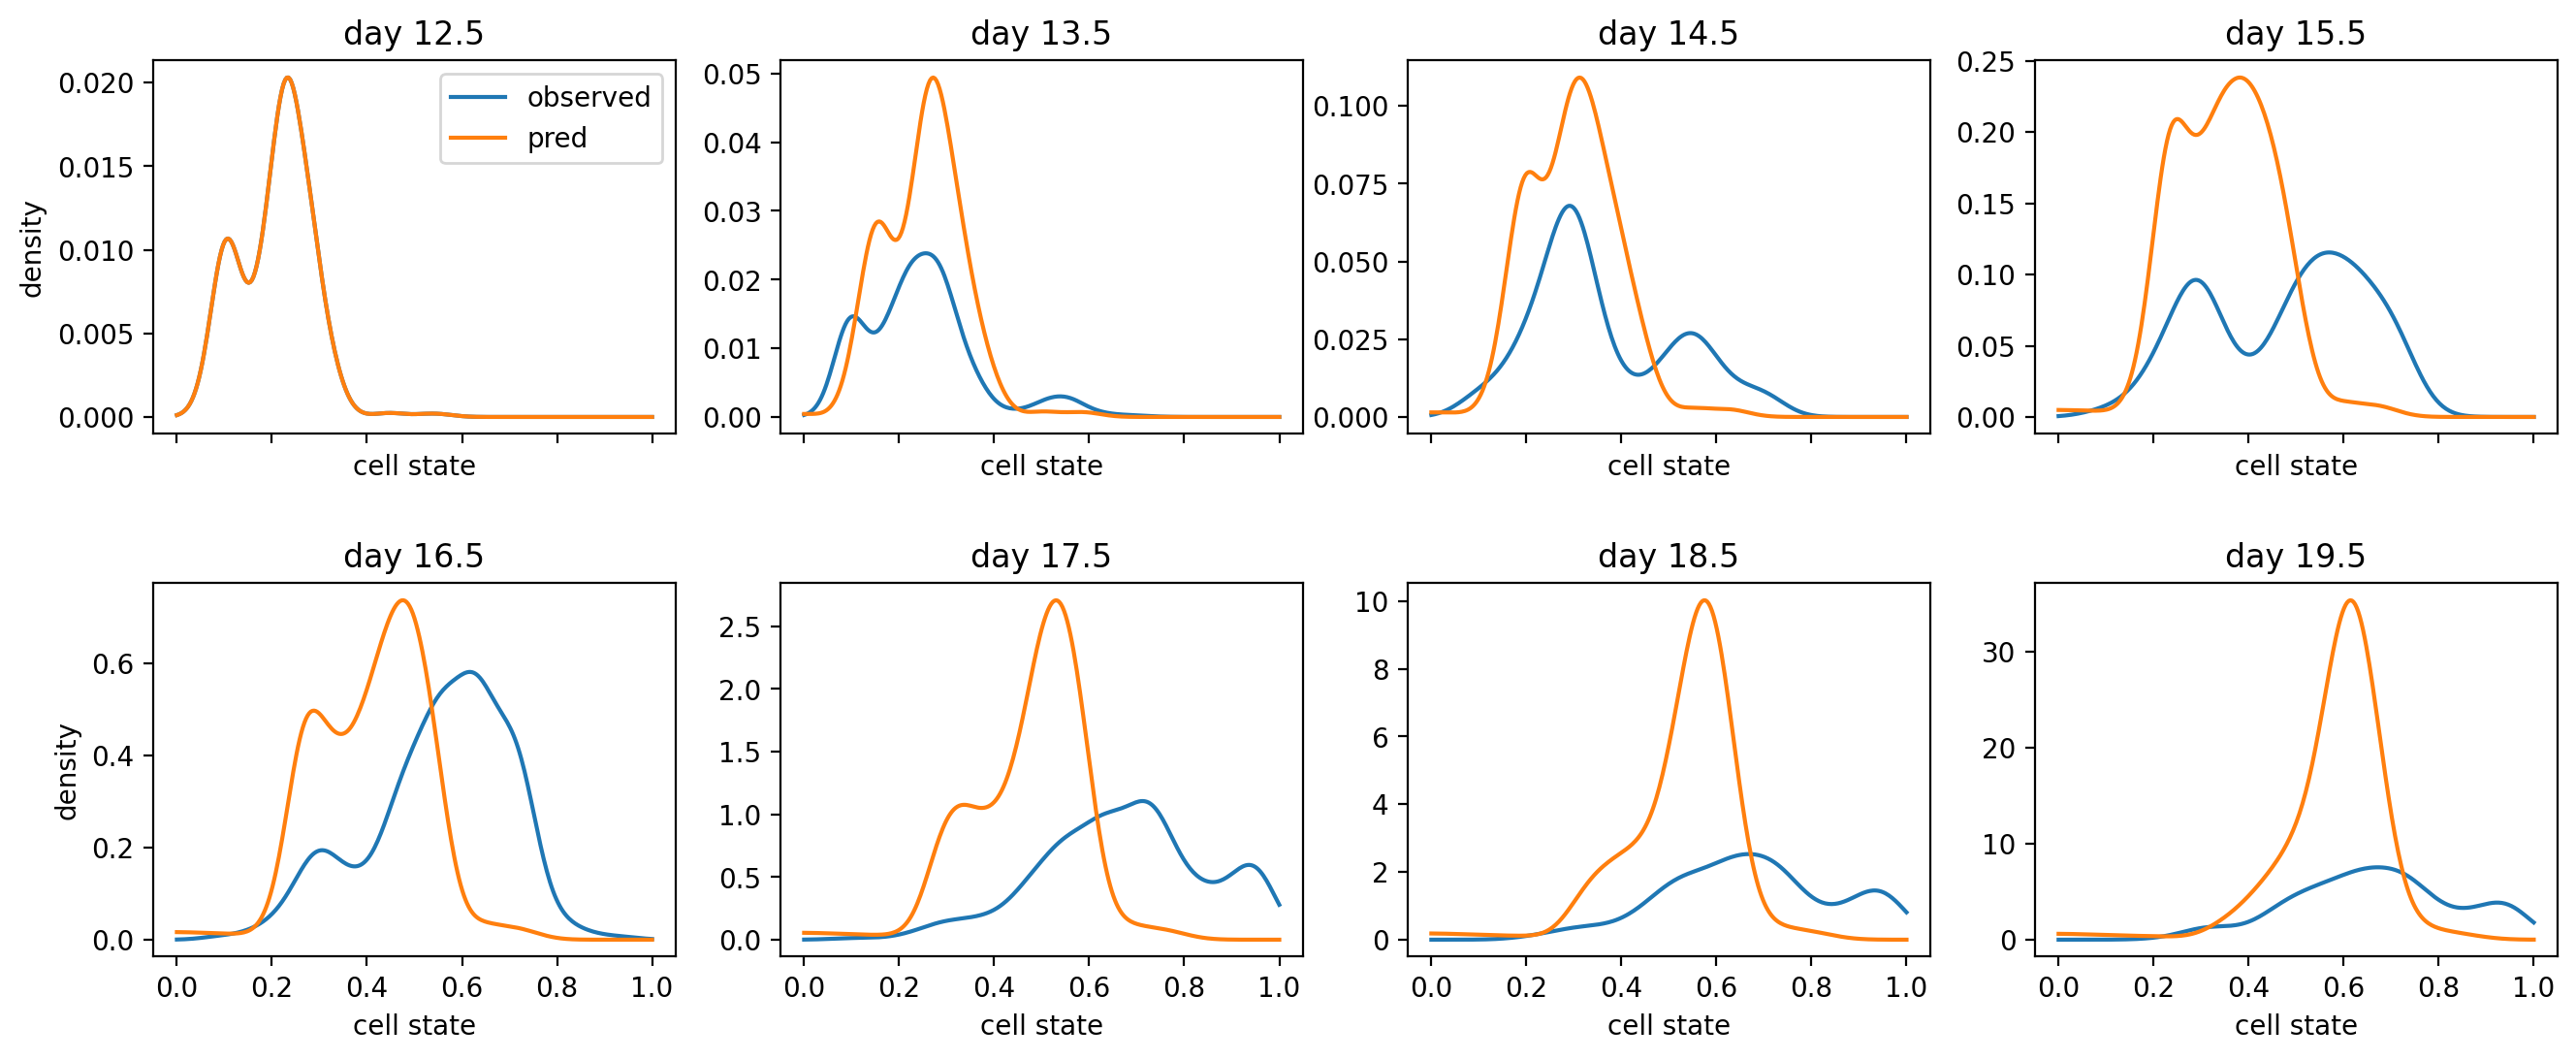

In [42]:
PINN.pl.density_by_time(u_b.detach().cpu().numpy()[:,:-1], u_int_all[:,:-1] , train_DS.popD['t']);

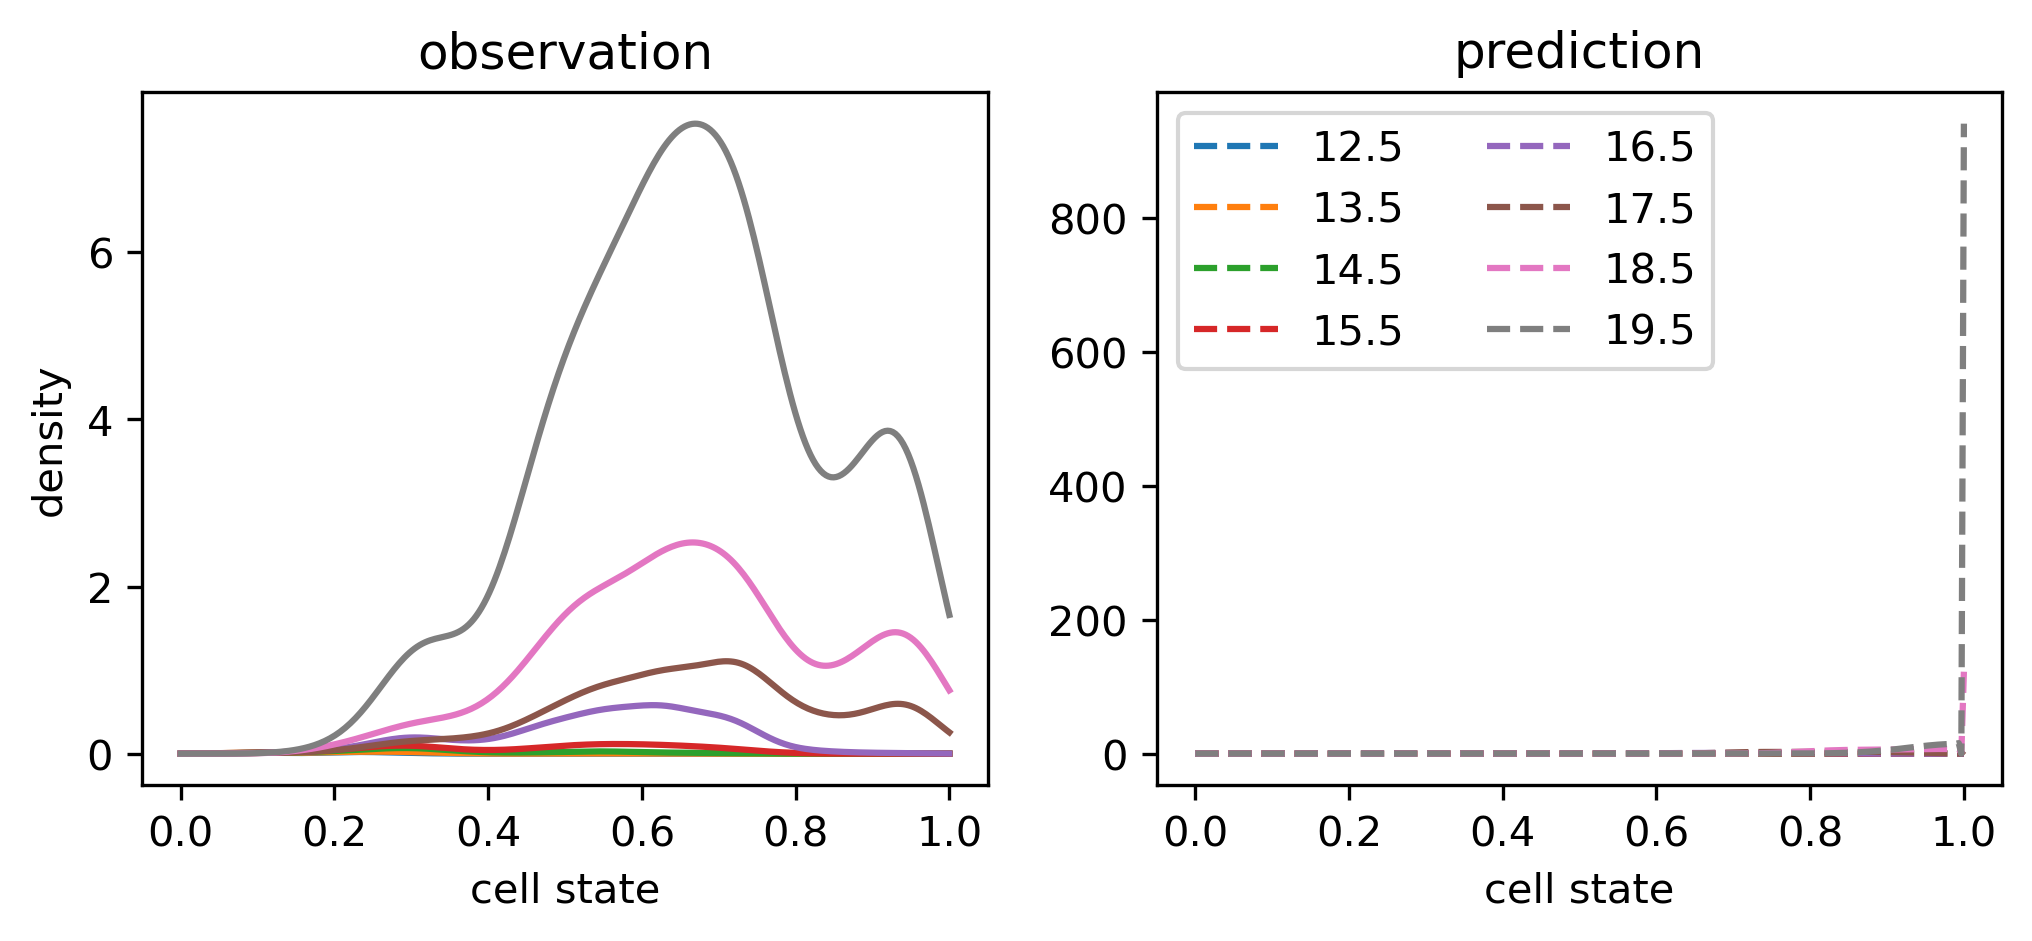

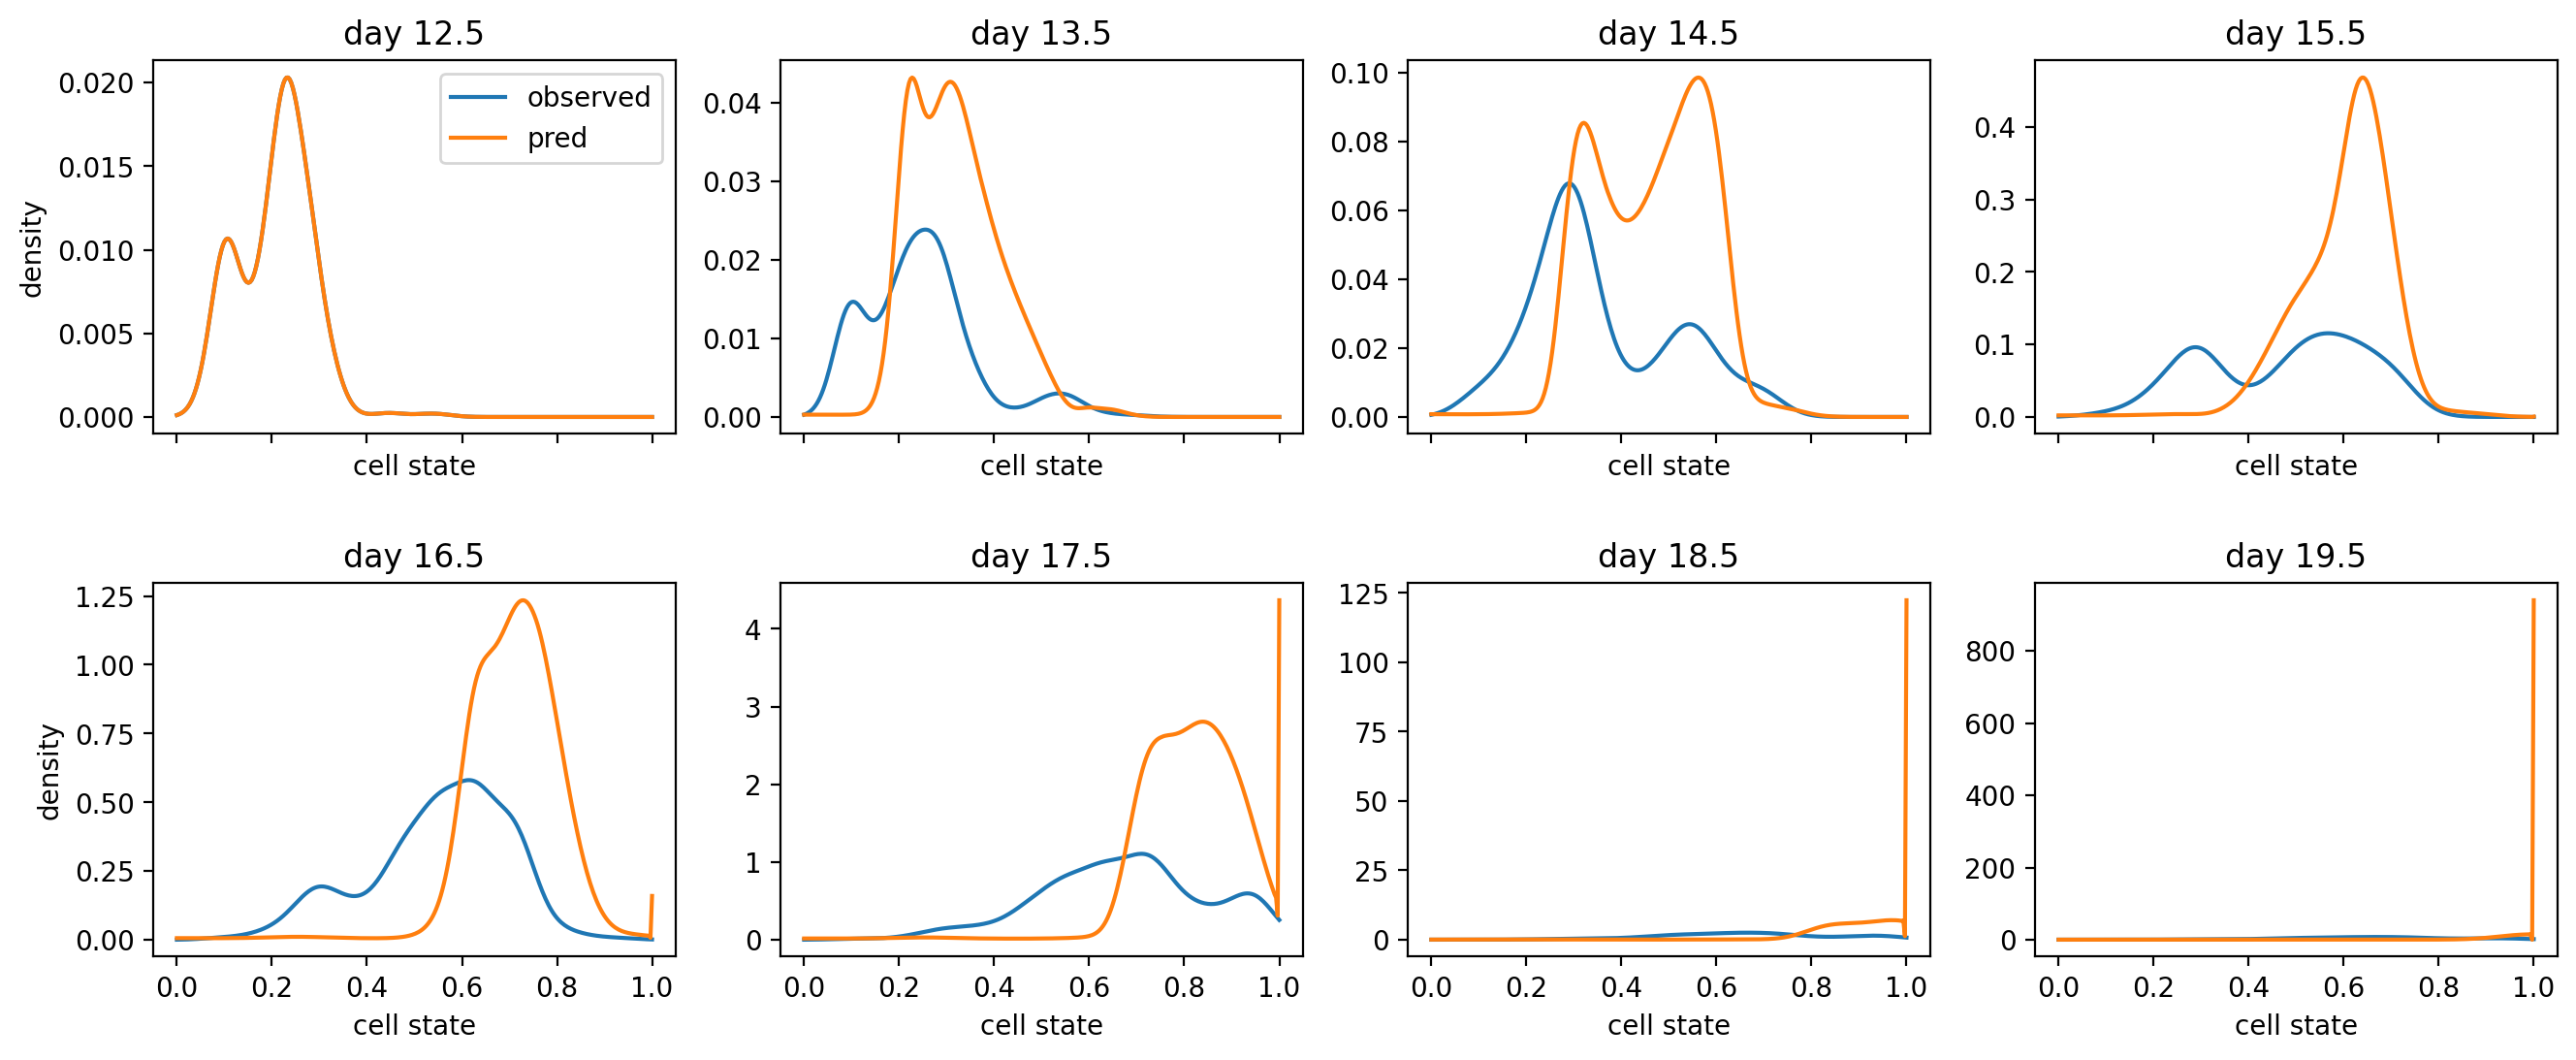

In [58]:
PINN.pl.density_by_time(u_b.detach().cpu().numpy(), u_int_all, train_DS.popD['t']);